In [2]:
# Classification Project
# Heart Disease Dataset

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score


# Load the dataset
df = pd.read_csv("heart.csv")

# Display the first 5 rows
print(df.head())

# Check the size of the dataset
print(df.shape)

# Check the columns and data types
print(df.info())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
(1025, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null 

In [3]:
# X = input variables
# y = target variable

X = df.drop("target", axis=1)
y = df["target"]

print(X.head())
print(y.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  
0   2     3  
1   0     3  
2   0     3  
3   1     3  
4   3     2  
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


In [4]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (820, 13)
Testing data: (205, 13)


In [5]:
# Create the scaler
scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data
X_test_scaled = scaler.transform(X_test)

In [6]:
# Create the Logistic Regression model
logistic_model = LogisticRegression()

# Train the model
logistic_model.fit(X_train_scaled, y_train)

# Make predictions
logistic_predictions = logistic_model.predict(X_test_scaled)

# Calculate the scores
logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_precision = precision_score(y_test, logistic_predictions)
logistic_recall = recall_score(y_test, logistic_predictions)
logistic_f1 = f1_score(y_test, logistic_predictions)

print("Logistic Regression")
print("Accuracy:", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall:", logistic_recall)
print("F1 Score:", logistic_f1)

Logistic Regression
Accuracy: 0.7951219512195122
Precision: 0.7563025210084033
Recall: 0.8737864077669902
F1 Score: 0.8108108108108109


In [7]:
# Create the Decision Tree model
tree_model = DecisionTreeClassifier(random_state=42)

# Train the model
tree_model.fit(X_train, y_train)

# Make predictions
tree_predictions = tree_model.predict(X_test)

# Calculate the scores
tree_accuracy = accuracy_score(y_test, tree_predictions)
tree_precision = precision_score(y_test, tree_predictions)
tree_recall = recall_score(y_test, tree_predictions)
tree_f1 = f1_score(y_test, tree_predictions)

print("Decision Tree")
print("Accuracy:", tree_accuracy)
print("Precision:", tree_precision)
print("Recall:", tree_recall)
print("F1 Score:", tree_f1)

Decision Tree
Accuracy: 0.9853658536585366
Precision: 1.0
Recall: 0.970873786407767
F1 Score: 0.9852216748768473


In [8]:
# Create the Random Forest model
forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
forest_model.fit(X_train, y_train)

# Make predictions
forest_predictions = forest_model.predict(X_test)

# Calculate the scores
forest_accuracy = accuracy_score(y_test, forest_predictions)
forest_precision = precision_score(y_test, forest_predictions)
forest_recall = recall_score(y_test, forest_predictions)
forest_f1 = f1_score(y_test, forest_predictions)

print("Random Forest")
print("Accuracy:", forest_accuracy)
print("Precision:", forest_precision)
print("Recall:", forest_recall)
print("F1 Score:", forest_f1)

Random Forest
Accuracy: 0.9853658536585366
Precision: 1.0
Recall: 0.970873786407767
F1 Score: 0.9852216748768473


In [9]:
# Get prediction probabilities

logistic_probability = logistic_model.predict_proba(X_test_scaled)[:, 1]
tree_probability = tree_model.predict_proba(X_test)[:, 1]
forest_probability = forest_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC
logistic_auc = roc_auc_score(y_test, logistic_probability)
tree_auc = roc_auc_score(y_test, tree_probability)
forest_auc = roc_auc_score(y_test, forest_probability)

print("Logistic Regression ROC-AUC:", logistic_auc)
print("Decision Tree ROC-AUC:", tree_auc)
print("Random Forest ROC-AUC:", forest_auc)

Logistic Regression ROC-AUC: 0.8787359604035789
Decision Tree ROC-AUC: 0.9854368932038835
Random Forest ROC-AUC: 1.0


In [10]:
# Make a table to compare the models

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        forest_accuracy
    ],

    "Precision": [
        logistic_precision,
        tree_precision,
        forest_precision
    ],

    "Recall": [
        logistic_recall,
        tree_recall,
        forest_recall
    ],

    "F1 Score": [
        logistic_f1,
        tree_f1,
        forest_f1
    ],

    "ROC-AUC": [
        logistic_auc,
        tree_auc,
        forest_auc
    ]
})

# Round the numbers
results = results.round(3)

# Print the table
print(results)

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression     0.795      0.756   0.874     0.811    0.879
1        Decision Tree     0.985      1.000   0.971     0.985    0.985
2        Random Forest     0.985      1.000   0.971     0.985    1.000


In [11]:
# Create confusion matrix
cm = confusion_matrix(y_test, forest_predictions)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[102   0]
 [  3 100]]


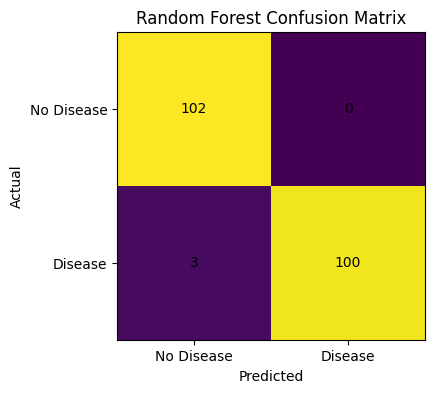

In [12]:
# Show the confusion matrix as a graph

plt.figure(figsize=(5, 4))

plt.imshow(cm)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["No Disease", "Disease"])
plt.yticks([0, 1], ["No Disease", "Disease"])

# Add numbers inside the boxes
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [13]:
# Find the model with the highest accuracy

if forest_accuracy > tree_accuracy and forest_accuracy > logistic_accuracy:
    print("The best model is Random Forest")
elif tree_accuracy > logistic_accuracy:
    print("The best model is Decision Tree")
else:
    print("The best model is Logistic Regression")

The best model is Decision Tree


I selected the Random Forest model because it had the best overall performance compared with Logistic Regression and Decision Tree. It achieved the highest Accuracy, Precision, Recall, F1-score, and ROC-AUC on the test data, making it the strongest model for predicting the target class in this dataset. The confusion matrix also shows that the Random Forest model made very few prediction errors.
